---
title: "Tutorial 3: Graph Theoretical Analysis of Functional Networks"
authors:
  - name: Sapolnach Prompiengchai
    affiliations:
      - University of Oxford
  - name: Aarushi Vardhan
    affiliations:
      - University of Toronto / University of Cambridge
---

# Graph Theoretical Analysis of Functional Networks

In the previous tutorial, we turned resting-state timeseries into **functional connectivity (FC)** matrices.  

That was our first step from raw signal to a network representation of the brain.

Next, we will learn how graph theory is a powerful way to computationally describe the functional brain networks! 

In this notebook, we will first build some mathematical intuition behind network science and graph theory and then translate it into code as we go.

---
Things to complete for this notebook:
- Add more figures on different types of graphs; connected vs disconnected graph; centrality/modularity;
- Notes to Programming Guide;

## What we mean by a network

A **network** is just a way to describe how things are connected.

The same language shows up everywhere:

- Social networks: people connected by friendships
- Transportation networks: cities connected by roads
- Computer networks: computers connected by cables
- Air transportation networks: airports connected by flights
- Brain networks: brain regions connected by statistical relationships (functional connectivity)

Graph theory gives us a compact vocabulary for this idea! Here are some of the terminologies you will encounter in graph theory:

- **node** or **vertex**: an entity, such as a person, a city, or a brain region
- **edge** or **link**: a relationship between two nodes
- **directed graph**: the edge has a direction, like a one-way street
- **undirected graph**: the edge has no direction, like a mutual friendship
- **weighted graph**: the edge has a strength or number attached to it

Watch this video for a compact introduction to the language of graph theory.  
The goal is to understand **nodes / vertices**, **edges**, **directed graphs**, and **undirected graphs**.

```{iframe} https://www.youtube.com/embed/82zlRaRUsaY
:width: 100%
```

Since much of the conventional graph theoretical analysis in neuroscience do not require multiplex graphs, the multiplex graph mentioned in the video is beyond the scope. 


## Why graph theory is useful for brain data

Brain data are naturally **relational**.

A single brain region does not operate in isolation. It continuously interacts with many other regions to support perception, cognition, and behaviour. Rather than studying each region separately, graph theory allows us to study the **network of interactions** between regions.

To do this, we first represent the brain as a **graph**:

* Each **parcellated brain region** is represented as a **node** (or **vertex**).
* The relationship between two regions is represented as an **edge**.

The exact meaning of an edge depends on the type of brain network being studied. For example:

* In **structural networks**, an edge might represent a white matter pathway (i.e., an **anatomical/structural connectivity**) connecting two regions.
* In **functional networks**, an edge represents a measure of **functional connectivity** between two regions.

In our previous tutorial, we estimated functional connectivity using the **Pearson correlation** between the resting-state fMRI time series of two brain regions. Therefore, in this tutorial, **the Pearson correlation coefficient becomes the weight of the edge connecting two nodes**.

Once we represent the brain as a graph of **nodes (brain regions)** and **edges (functional connectivity)**, graph theory provides a rich set of tools to study the organization of the brain at multiple scales:

* **Region-to-region:** How strongly connected is an individual brain region?
* **Modules:** How do groups of regions cluster together into communities or modules?
* **Global scale:** How efficiently is information integrated across the entire brain?

This is the central idea of **network neuroscience**: instead of viewing the brain as a collection of isolated regions, we study it as an organized system of interacting brain regions whose collective organization gives rise to brain function.


## From timeseries to FC to graph 

In Tutorial 2, we built FC matrices from region-wise timeseries.

Here, we take the next step and treat that FC matrix as a graph:

- each region is a node
- each FC value is a relationship between two nodes
- the whole matrix becomes a weighted network

In other words, our FC matrix is a graph!!

## FC: A directed or undirected graph?

For a functional brain network, the **nodes** are brain regions and the **edges** represent functional connectivity between them.

Because Pearson correlation is **symmetric**, the correlation between regions A and B is identical to the correlation between B and A:

$$
r(A,B) = r(B,A)
$$

Think back to the example from the video: saying **James is married to Paul** conveys the same relationship as saying **Paul is married to James**. The relationship has no inherent direction.

Likewise, if region A is positively correlated with region B, then region B is equally positively correlated with region A. We do not know the "directionality" of this relationship (i.e., we cannot claim whether region A activities causes B and not vice versa). 

For this reason, functional connectivity networks based on Pearson correlation are typically represented as **undirected graphs**.

If we instead used a measure that estimates the **direction of influence** between brain regions (e.g., effective connectivity), then the network would be represented as a **directed graph**. 

For this tutorial, let's use our undirected graph of an already defined FC as Pearson correlation between two nodes or region. 


# Coding Part 1 (Preparation): Graph Theoretical Analysis

Let's now code! As usual, we'll import the packages required. Make sure you install networkx. 

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import networkx as nx
from pycirclize import Circos


## Set up the file paths

We will follow the same project structure used in **Tutorial 2**.

This notebook expects the following files generated during the functional connectivity tutorial:

- `mean_fc.npy` – the **group-average functional connectivity matrix**, obtained by averaging the FC matrices across all participants.
- `subject_fc_stack.npy` – a stack containing the **individual FC matrix for every participant**, with shape *(subjects × regions × regions)*.
- `region_names.npy` – the names of the **100 brain regions (nodes)** defined by the Schaefer-100 atlas.
- `subject_ids.npy` – the participant IDs corresponding to each individual FC matrix.

If the notebook lives inside your project folder, `Path.cwd()` is usually sufficient to locate these files. If not, replace it with the path to your LEMON project directory.

In [2]:
# Option 1: use the current working directory if the notebook lives inside the project folder
# PROJECT_DIR = Path.cwd()

# Option 2: manually specify your project directory if needed
PROJECT_DIR = Path("/Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026")

RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fc_stack_path = RESULTS_DIR / "subject_fc_stack.npy"
subject_ids_path = RESULTS_DIR / "subject_ids.npy"
region_names_path = RESULTS_DIR / "region_names.npy"
mean_fc_path = RESULTS_DIR / "mean_fc.npy"

print("Project directory:", PROJECT_DIR)
print("Results directory:", RESULTS_DIR)
print("Mean FC file:", mean_fc_path)
print("FC stack file:", fc_stack_path)
print("Region names file:", region_names_path)
print("Subject IDs file:", subject_ids_path)

Project directory: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026
Results directory: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/results
Mean FC file: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/results/mean_fc.npy
FC stack file: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/results/subject_fc_stack.npy
Region names file: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/results/region_names.npy
Subject IDs file: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/results/subject_ids.npy


## Load the saved arrays

We will start with the mean FC matrix because it gives us one clean network summary across the sample.

We also load the subject-level stack and metadata so that this notebook can be extended later.

In [3]:
mean_fc = np.load(mean_fc_path, allow_pickle=True)
fc_stack = np.load(fc_stack_path, allow_pickle=True)
region_names = np.load(region_names_path, allow_pickle=True)
subject_ids = np.load(subject_ids_path, allow_pickle=True)

print("Loaded mean FC:", None if mean_fc is None else mean_fc.shape) # if mean_fc doesn't exist, print None
print("Loaded FC stack:", None if fc_stack is None else fc_stack.shape)
print("Loaded region names:", None if region_names is None else region_names.shape)
print("Loaded subject IDs:", None if subject_ids is None else subject_ids.shape)


Loaded mean FC: (100, 100)
Loaded FC stack: (220, 100, 100)
Loaded region names: (100,)
Loaded subject IDs: (220,)


In [4]:
# region_names = region_names.tolist()
# subject_ids = subject_ids.tolist()

print("Number of subjects:", len(subject_ids))
print("First five subject IDs:", subject_ids[:5])
print("Sample region names:", region_names[:5])

Number of subjects: 220
First five subject IDs: ['sub-010002' 'sub-010003' 'sub-010004' 'sub-010005' 'sub-010006']
Sample region names: ['7Networks_LH_Vis_1' '7Networks_LH_Vis_2' '7Networks_LH_Vis_3'
 '7Networks_LH_Vis_4' '7Networks_LH_Vis_5']


## Preparing the functional connectivity matrix for graph analysis

Before we can represent our functional connectivity (FC) matrix as a graph, we need to make several preprocessing decisions. These choices influence the resulting network and, consequently, the graph metrics we compute. There is **no universally accepted approach**! Different studies make different choices depending on their scientific question.

### The diagonal

In a correlation matrix, every brain region has a correlation of **1** with itself. These values appear along the diagonal of the matrix.

However, self-connections are generally **not considered meaningful edges** in graph theory because every node would simply be connected to itself with maximum strength. Including these values would artificially inflate several graph metrics without providing biologically useful information.

For this reason, it is standard practice to set the diagonal to zero before constructing a graph of functional networks.

### Should we keep every connection?

Another important decision is whether to include **all pairwise functional connections** or only a subset of them.

Functional connectivity matrices contain correlations ranging from very weak to very strong. While stronger correlations are often interpreted as more reliable interactions between brain regions, weaker correlations may reflect noise, physiological artefacts, or random fluctuations rather than meaningful functional relationships.

Several strategies are commonly used in network neuroscience:

* **Keep all connections** (weighted network), allowing every edge to contribute according to its correlation strength.
* **Apply a correlation threshold**, retaining only connections whose absolute correlation exceeds a chosen value (e.g., (|r| > 0.2)).
* **Apply a density threshold**, retaining only a fixed proportion of the strongest connections (e.g., the top 20% of edges), which ensures that networks from different participants have the same number of edges.
* **Binarize the network**, converting surviving edges to either present (1) or absent (0), thereby ignoring differences in connection strength.

Each approach has advantages and limitations. Thresholds can help reduce weak or potentially spurious connections, but they are inherently somewhat arbitrary, and different thresholds may produce different network properties. Density thresholding improves comparability across participants but may remove biologically meaningful weak connections. Weighted analyses avoid choosing a threshold altogether but require graph measures that appropriately account for edge weights.

In this tutorial, let's try and explore different strategies to produce a graph. 

### What about negative correlations?

Pearson correlation produces values between **-1 and 1**, meaning that some pairs of brain regions may exhibit **negative correlations**. A negative correlation indicates that when one region's activity tends to increase, the other's tends to decrease.

Although negative correlations can be biologically meaningful, they introduce important challenges for graph analysis.

Many classical graph theory measures—such as shortest path length, clustering coefficient, efficiency, and betweenness centrality—were originally developed for networks with **non-negative edge weights**. When negative weights are present, the interpretation of concepts such as "distance", "connection strength", or "information flow" becomes less straightforward. Consequently, many graph analysis tools either ignore negative edges or require specialized algorithms designed specifically for signed networks.

One common solution is to **take the absolute value** of the connectivity matrix. This converts all correlations to positive values while preserving the magnitude of each relationship. For instance, r = -0.2 between nodes A and B would be converted into +0.2. 

Importantly, taking the absolute value **does not change the topology of the network**. In other words, the same pairs of brain regions remain connected, and stronger relationships remain stronger than weaker ones. The only information that is removed is **whether the original relationship was positive or negative**.

For this tutorial, we will use the **absolute value of the correlation matrix**. This is a common first-pass approach in the neuroimaging literature and allows us to compute a wide range of standard graph metrics without introducing additional methodological complexity.



## Code: Prepare the FC matrix for graph analysis

In this section, we will prepare the group-average functional connectivity matrix for graph analysis.

Specifically, we will:

- **Remove self-connections** by setting all diagonal entries to zero using `np.fill_diagonal()`.
- **Take the absolute value** of every correlation using `np.abs()`, so that all edge weights are non-negative while preserving the strength of each connection.
- **Visualize the original and absolutized matrices side-by-side** to see how taking the absolute value changes the connectivity matrix.
- **Visualize the difference between the two matrices**, which highlights exactly which connections were modified by the absolutization step. Because positive correlations remain unchanged, only connections that were originally negative will appear in this difference matrix.

In [5]:
# Keep a raw copy for comparison
mean_fc_raw = np.array(mean_fc, dtype=float, copy=True)

# Remove self-connections
np.fill_diagonal(mean_fc_raw, 0)

# Absolutize to keep connection strength and remove sign
mean_fc_abs = np.abs(mean_fc_raw)

# Keep the diagonal at zero after taking the absolute value
np.fill_diagonal(mean_fc_abs, 0)

mean_fc_raw_df = pd.DataFrame(mean_fc_raw, index=region_names, columns=region_names)
mean_fc_abs_df = pd.DataFrame(mean_fc_abs, index=region_names, columns=region_names)

print("Raw mean FC shape:", mean_fc_raw_df.shape)
print("Absolute mean FC shape:", mean_fc_abs_df.shape)

Raw mean FC shape: (100, 100)
Absolute mean FC shape: (100, 100)


In [6]:
mean_fc_abs_df

,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,7Networks_LH_Vis_9,7Networks_LH_SomMot_1,...,7Networks_RH_Default_Temp_1,7Networks_RH_Default_Temp_2,7Networks_RH_Default_Temp_3,7Networks_RH_Default_PFCv_1,7Networks_RH_Default_PFCv_2,7Networks_RH_Default_PFCdPFCm_1,7Networks_RH_Default_PFCdPFCm_2,7Networks_RH_Default_PFCdPFCm_3,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2
7Networks_LH_Vis_1,0.000000,0.367295,0.442653,0.234164,0.327964,0.436472,0.407784,0.303896,0.355254,0.390979,...,0.437213,0.447959,0.328788,0.334771,0.149295,0.395692,0.270114,0.399102,0.666378,0.465049
7Networks_LH_Vis_2,0.367295,0.000000,0.768020,0.606942,0.717048,0.565144,0.620145,0.814675,0.666409,0.465444,...,0.262783,0.319341,0.359793,0.301966,0.328159,0.148721,0.224049,0.204320,0.249923,0.139255
7Networks_LH_Vis_3,0.442653,0.768020,0.000000,0.414145,0.699393,0.807055,0.557913,0.772600,0.849704,0.464349,...,0.183551,0.294065,0.315464,0.248494,0.280268,0.101242,0.137606,0.182927,0.327115,0.110643
7Networks_LH_Vis_4,0.234164,0.606942,0.414145,0.000000,0.582094,0.322120,0.446216,0.577044,0.376725,0.328991,...,0.267797,0.233983,0.281167,0.265640,0.275062,0.128493,0.193200,0.157268,0.158520,0.136014
7Networks_LH_Vis_5,0.327964,0.717048,0.699393,0.582094,0.000000,0.726754,0.407792,0.636254,0.670448,0.345259,...,0.250823,0.222997,0.270834,0.290954,0.294017,0.157459,0.201598,0.202665,0.288319,0.168486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7Networks_RH_Default_PFCdPFCm_1,0.395692,0.148721,0.101242,0.128493,0.157459,0.172366,0.146962,0.022016,0.090864,0.242770,...,0.540804,0.447713,0.428593,0.606815,0.291470,0.000000,0.710507,0.555837,0.528438,0.718115
7Networks_RH_Default_PFCdPFCm_2,0.270114,0.224049,0.137606,0.193200,0.201598,0.163600,0.196415,0.084315,0.107489,0.238059,...,0.637114,0.472014,0.604669,0.680893,0.572446,0.710507,0.000000,0.601074,0.329632,0.596204
7Networks_RH_Default_PFCdPFCm_3,0.399102,0.204320,0.182927,0.157268,0.202665,0.223761,0.196385,0.085290,0.153514,0.246684,...,0.587819,0.270287,0.390190,0.469209,0.311246,0.555837,0.601074,0.000000,0.525656,0.562100
7Networks_RH_Default_pCunPCC_1,0.666378,0.249923,0.327115,0.158520,0.288319,0.437375,0.280148,0.171598,0.326169,0.288753,...,0.433612,0.380658,0.314080,0.317238,0.058568,0.528438,0.329632,0.525656,0.000000,0.703942


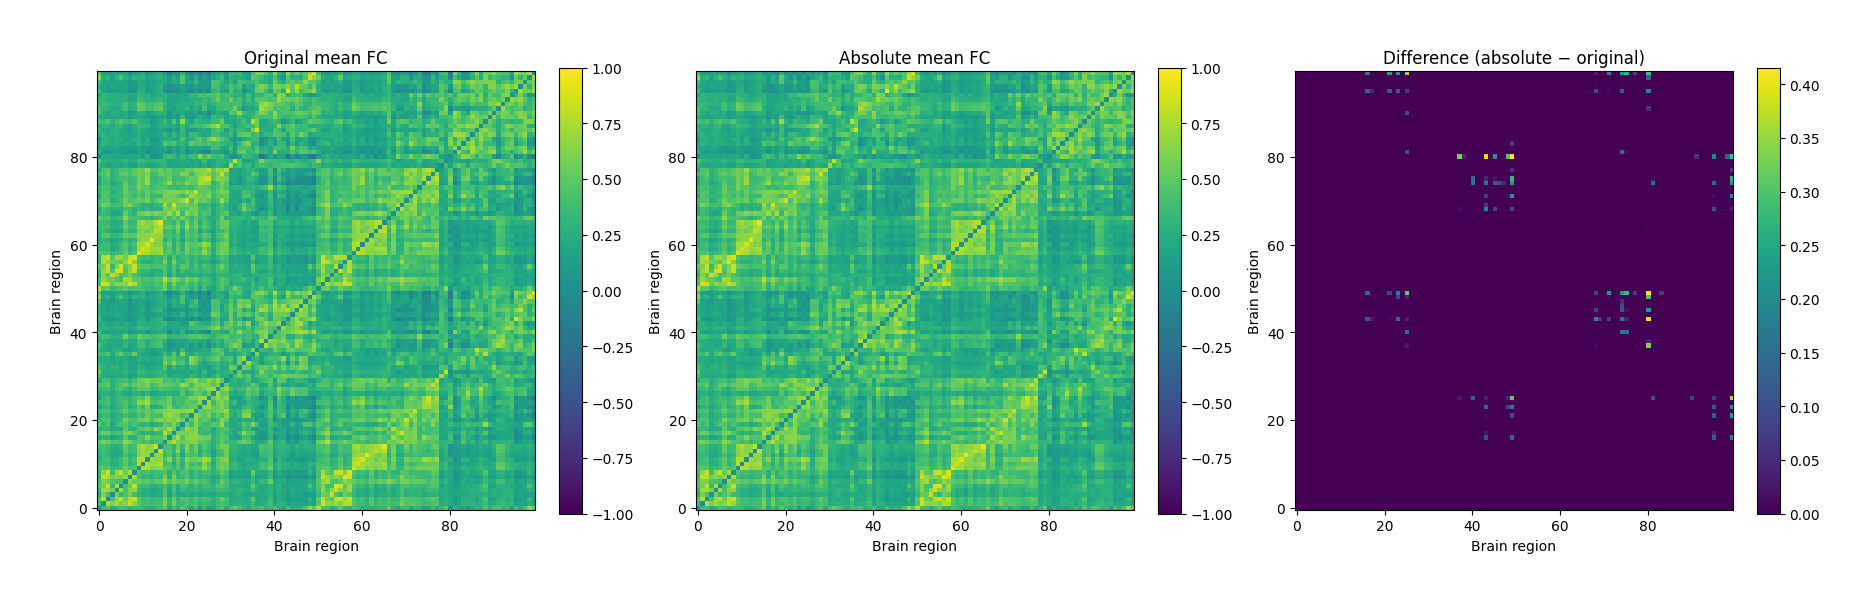

In [7]:
difference = mean_fc_abs - mean_fc_raw

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original
im0 = axes[0].imshow(
    mean_fc_raw,
    vmin=-1, vmax=1,
    cmap="viridis",
    origin="lower"
)
axes[0].set_title("Original mean FC")

# Absolutized
im1 = axes[1].imshow(
    mean_fc_abs,
    vmin=-1, vmax=1,
    cmap="viridis",
    origin="lower"
)
axes[1].set_title("Absolute mean FC")

# Difference
im2 = axes[2].imshow(
    difference,
    cmap="viridis",
    origin="lower"
)
axes[2].set_title("Difference (absolute − original)")

for ax in axes:
    ax.set_xlabel("Brain region")
    ax.set_ylabel("Brain region")

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

```{figure}
---
width: 100%
name: fig-absolute-fc
---

The first matrix (left) shows the original correlations. Blue cells correspond to negative correlations, whereas red cells correspond to positive correlations. After taking the absolute value, all entries become non-negative (middle). The difference matrix (absolute − original) highlights where the changes occurred. Values close to zero indicate connections that were already positive, whereas brighter values indicate pairs of brain regions whose negative correlations were converted into positive values (right).
```

## Look at the distribution of edge weights

Before computing graph-theoretical measures, it is good practice to inspect the distribution of the edge weights in the network.

Why is this useful?

* **Quality control:** Unusual values or unexpected patterns may indicate problems with preprocessing or data quality.
* **Understand the network:** The distribution tells us whether the network is dominated by many weak connections, a few very strong connections, or a mixture of both.
* **Guide analysis choices:** Understanding the weight distribution can help inform later decisions, such as whether to threshold the network, retain all weighted connections, or investigate potential outliers.

Functional connectivity matrices are often characterized by **many relatively weak connections and fewer strong connections**. As a result, the distribution of edge weights is typically right-skewed, meaning that most connections have relatively small weights, while only a few have much larger weights. In a histogram, this appears as a peak on the left with a long tail extending to the right, rather than the symmetric bell shape of a Gaussian distribution.

Applying a logarithmic transformation compresses the largest values while spreading out the smaller ones. This often produces a distribution that is **more symmetric** and therefore easier to visualize and interpret. Importantly, the log transformation here is used **only for visualization**—we will continue to use the original edge weights for our graph analysis.

### Code: Visualizing the distribution of edge weights

The functional connectivity matrix is **symmetric**, meaning the connection between regions A and B is identical to the connection between B and A. If we included the entire matrix, every connection would therefore be counted twice.

To avoid double-counting, we first extract only the **upper triangular** portion of the matrix (excluding the diagonal). Each remaining value represents one unique edge in the functional brain network.

Next, we:

* remove any zero-valued entries,
* plot the distribution of the absolute edge weights,
* apply a base-10 logarithmic transformation to the edge weights,
* and plot the transformed distribution for comparison.

Comparing these two histograms provides a useful overview of the network before computing graph-theoretical measures.

In [8]:
# The FC matrix is symmetric:
# FC(A, B) = FC(B, A)
#
# This means every functional connection appears twice:
# once above the diagonal and once below it (i.e., they are symmetric). 
#
# To avoid counting each edge twice, we keep only the
# upper triangular part of the matrix (excluding the diagonal).

upper = np.triu_indices_from(mean_fc_abs, k=1) # triu_indices_from = "return the indices for the upper-triangle of array"



# Extract the unique edge weights
weights = mean_fc_abs[upper]

# Remove zero-valued entries (self-connections or absent edges)
weights = weights[weights > 0]

# Compute the log10 of the edge weights.
# This is used only for visualization.
log_weights = np.log10(weights)

Let's try visualize what we mean by working with the upper triangular part of the matrix. 

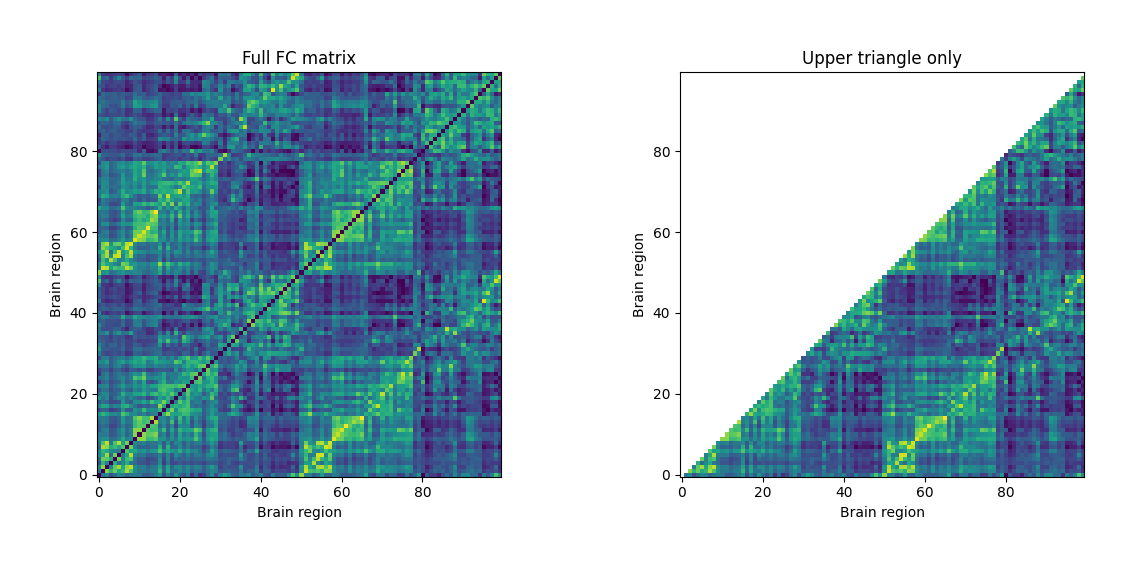

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Original matrix
axes[0].imshow(mean_fc_abs, cmap="viridis", origin="lower")
axes[0].set_title("Full FC matrix")
axes[0].set_xlabel("Brain region")
axes[0].set_ylabel("Brain region")

# Upper triangle only
mask = np.tril(np.ones_like(mean_fc_abs, dtype=bool), k=0)
upper_only = np.ma.masked_where(mask, mean_fc_abs)

axes[1].imshow(upper_only, cmap="viridis", origin="lower")
axes[1].set_title("Upper triangle only")
axes[1].set_xlabel("Brain region")
axes[1].set_ylabel("Brain region")

plt.tight_layout()
plt.show()


```{figure}
---
width: 100%
name: fig-upper-triang
---

Because the functional connectivity matrix is symmetric, every connection appears twice: once above and once below the diagonal. For an undirected graph, each pair of brain regions represents a single edge, so we retain only the upper triangular portion of the matrix when extracting edge weights.
```

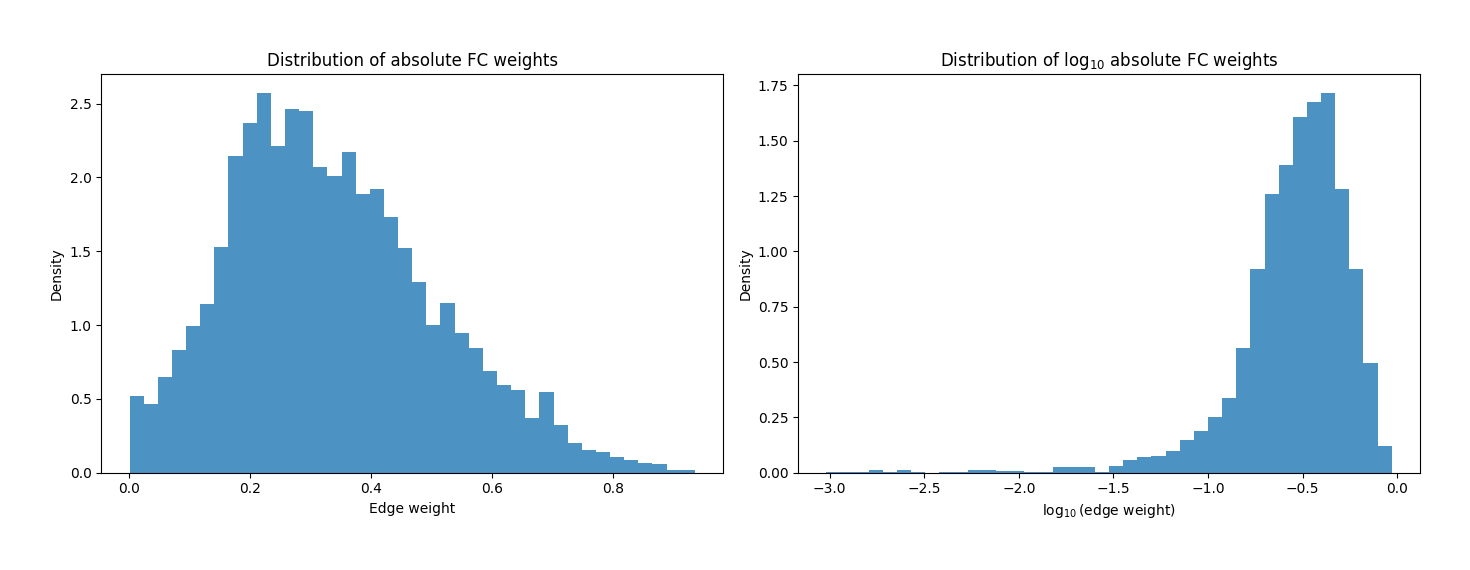

In [10]:
# Plot the distribution of the unique edge weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of the original absolute FC weights
axes[0].hist(weights, bins=40, density=True, alpha=0.8)
axes[0].set_title("Distribution of absolute FC weights")
axes[0].set_xlabel("Edge weight")
axes[0].set_ylabel("Density")

# Distribution after applying a log10 transformation.
# This often produces a more symmetric distribution,
# making it easier to visualize the spread of weights.
axes[1].hist(log_weights, bins=40, density=True, alpha=0.8)
axes[1].set_title("Distribution of log$_{10}$ absolute FC weights")
axes[1].set_xlabel(r"$\log_{10}(\mathrm{edge\ weight})$")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

# Coding Part 2 (Analysis): Graph Theoretical Analysis

In **Coding Part 1**, we prepared our functional connectivity (FC) matrix for graph analysis. Along the way, we introduced several important methodological choices that researchers commonly make when constructing functional brain networks, including:

- removing **self-connections** by setting the diagonal to zero,
- deciding how to handle **negative edge weights**,
- considering whether to retain **all connections** or apply different **thresholding strategies**, and
- understanding why we extract only the **upper triangular** portion of the FC matrix when examining the distribution of unique edge weights in an undirected network.

We also prepared our data by **absolutizing the FC matrix** and explored the distribution of edge weights. At this point, our FC matrix is ready to be represented as a graph.

In **Coding Part 2**, we will use the **functional connectivity matrix** to construct a graph using the **NetworkX** Python package. We will explore several thresholding approaches for constructing functional brain networks before computing a selection of commonly used graph-theoretical measures. Along the way, we will build intuition for what these metrics quantify and how they help us characterize the organization of functional brain networks.

## Create a graph from the mean FC matrix

So far, we have represented our functional brain network as a **functional connectivity (FC) matrix**. While this matrix is convenient for storing the pairwise relationships between brain regions, graph theory algorithms require a different representation: a **graph**.

Using the **NetworkX** library, we can convert our FC matrix into a graph object. We will store this graph in a variable called **`G`**.

You can think of **`G`** as a digital representation of the network itself. Rather than storing rows and columns like a matrix, `G` stores information about:

- **which brain regions are nodes**,
- **which pairs of regions are connected by edges**, and
- **the weight associated with each edge** (in our case, the absolute functional connectivity).

To build the graph, NetworkX interprets the FC matrix as an **adjacency matrix** (a mathematical way of representing a graph as a square matrix), where

- each **row (and corresponding column)** represents a brain region (a node),
- each **non-zero entry** in the matrix becomes an **edge** connecting two nodes,
- and the value of that entry becomes the **weight** of the edge.

Because our FC matrix is symmetric, NetworkX automatically constructs an **undirected graph**.

Finally, because we previously set the diagonal to zero, self-connections are not expected. Nevertheless, we remove any self-loops as a simple safety check before continuing the analysis.

Thus, in our code below, we will
* create a graph `G` from our absolutized mean FC
* remove self-connections
* check if graph is connected (i.e., for every pair of distinct nodes, there's a path between them)


In [11]:
# Work with an explicit copy so the original matrix stays untouched
matrix = np.array(mean_fc_abs, dtype=float, copy=True)

# Creating a graph from the FC matrix
G_full = nx.from_numpy_array(matrix)

# Relabel nodes from numeric indices to brain-region names
mapping = {i: name for i, name in enumerate(region_names)}
G_full = nx.relabel_nodes(G_full, mapping)

# Remove self-loops
G_full.remove_edges_from(nx.selfloop_edges(G_full))

print("Full graph")
print("Number of nodes:", G_full.number_of_nodes())
print("Number of edges:", G_full.number_of_edges())
print("Is connected?:", nx.is_connected(G_full))


Full graph
Number of nodes: 100
Number of edges: 4950
Is connected?: True


## Thresholding, sparsity, and density

Before graph analysis, we often need to decide how many connections to keep.

A **threshold** is one simple way to make the network sparser:

- if an edge weight is **below** the threshold, we set it to zero;
- if it is **above** the threshold, we keep it.

This is useful because very weak connections may be noisy or hard to interpret. The downside is that the threshold is partly arbitrary: different thresholds can produce different network topologies and therefore different graph metrics.

Another commonly used idea is **density thresholding**, where we keep a fixed proportion of the strongest edges so that graphs from different subjects have the same number of connections. That can be helpful for comparisons, but it also means weaker edges are discarded by design.

Here, we use a simple **hard threshold on the correlation weight** to illustrate how sparsity changes the graph.

Remember: for an undirected graph, density is the proportion of all possible edges that are actually present. After thresholding, an edge is considered present if its weight is non-zero, and absent if its weight is zero.

---

For example, suppose we have a network with **100 brain regions (nodes)**. If every brain region could connect to every other brain region, how many unique connections would there be?

- The first region can connect to the other **99** regions.
- The second region can also connect to **99** regions.
- Repeating this for all 100 regions gives:

$$
100 \times 99 = 9900
$$

However, because our graph is **undirected**, every connection has been counted **twice**. For example, the connection between regions A and B is the same as the connection between B and A.

To count each connection only once, we divide by 2:

$$
\frac{100 \times 99}{2} = 4950.
$$

Therefore, a network with 100 nodes can contain a maximum of **4,950 unique undirected edges**.


If, after thresholding, only **990** connections have non-zero weights, then the network density is

  $$
  \frac{990}{4950} = 0.20.
  $$

This means that **20% of all possible connections are present**, while the remaining **80% have been removed** by thresholding.

### Code: Compare graph density under different thresholds

The code below will:

- create two thresholded versions of the FC matrix by keeping only connections with weights greater than **0.5** (`matrix_50`) and **0.75** (`matrix_75`),
- convert each thresholded matrix into a graph using **NetworkX**,
- remove any self-connections as a safety check,
- compute the **graph density** of each network, and
- visualize how increasing the threshold makes the connectivity matrix progressively **sparser** by removing weaker connections.

In [12]:
# Create sparser versions of the same matrix
matrix_50 = matrix.copy()
matrix_75 = matrix.copy()

matrix_50[matrix_50 <= 0.50] = 0 # if edge (or correlation) < 0.5, make that value zero
matrix_75[matrix_75 <= 0.75] = 0 # if edge (or correlation) < 0.75, make that value zero

# Turn each matrix into a graph
G_50 = nx.from_numpy_array(matrix_50)
G_75 = nx.from_numpy_array(matrix_75)

# Relabel nodes so the graphs use region names
G_50 = nx.relabel_nodes(G_50, mapping)
G_75 = nx.relabel_nodes(G_75, mapping)

# Remove self-loops as a safety check
G_50.remove_edges_from(nx.selfloop_edges(G_50))
G_75.remove_edges_from(nx.selfloop_edges(G_75))

# Compute graph statistics
graphs = {
    "All-to-all": G_full,
    "Weight > 0.5": G_50,
    "Weight > 0.75": G_75,
}

summary = []

# Calculate graph statistics for each graph in `graphs`
for name, G in graphs.items():

    # Number of nodes
    n_nodes = G.number_of_nodes()

    # Maximum possible number of undirected edges
    possible_edges = n_nodes * (n_nodes - 1) // 2

    # Number of edges that remain after thresholding
    observed_edges = G.number_of_edges()

    summary.append(
        {
            "Network": name,
            "Possible edges": possible_edges,
            "Edges retained": observed_edges,
            "Connected graph": nx.is_connected(G),
            "Density": nx.density(G),
        }
    )

density_df = (
    pd.DataFrame(summary)
    .set_index("Network")
)

display(density_df)


,Possible edges,Edges retained,Connected graph,Density
Network,,,,
All-to-all,4950,4950,True,1.000000
Weight > 0.5,4950,858,True,0.173333
Weight > 0.75,4950,75,False,0.015152


From the results above, the density of a graph thresholded at weight > 0.5 is 
$$
    858/4950 = 0.173
$$

Next, let's visualize the thresholded matrix.

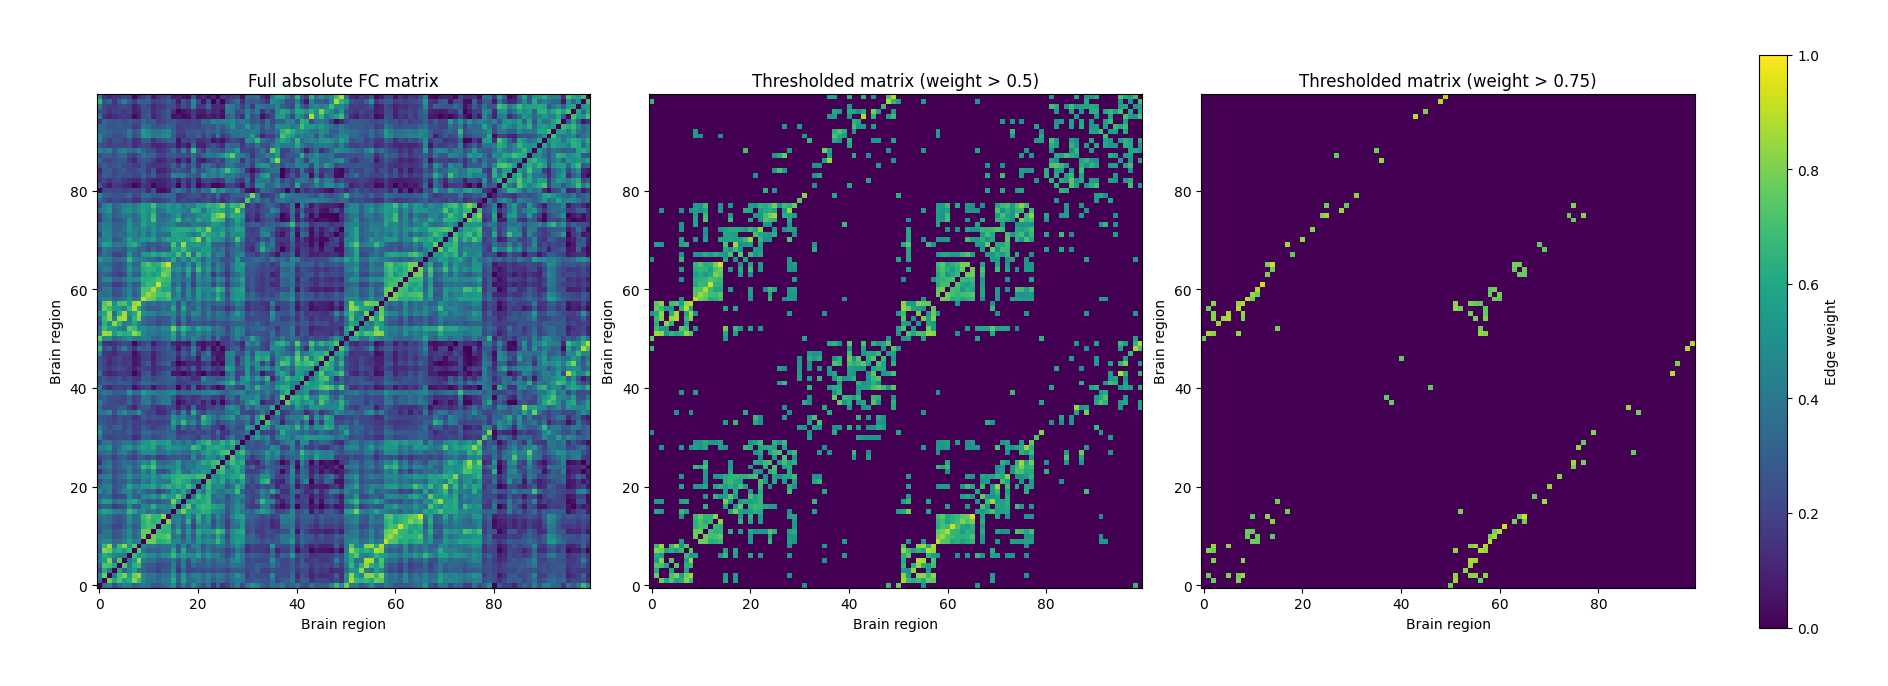

In [13]:
# Visualize the effect of thresholding on the matrix itself
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# Store all three matrices and their corresponding titles in lists
mats = [matrix, matrix_50, matrix_75]
titles = ["Full absolute FC matrix", "Thresholded matrix (weight > 0.5)", "Thresholded matrix (weight > 0.75)"]

# For each matrix, produce the figure. 
for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(mat, origin="lower", cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Brain region")
    ax.set_ylabel("Brain region")

# Add colorbar on the right and label as "Edge Weight"
fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04, label="Edge weight")

# Show plot
plt.show()

## Nodal degree and nodal strength

Now that we have represented the brain as a graph, we can begin asking questions about **individual brain regions (nodes)**.

One simple question is:

> **How well connected is a particular brain region to the rest of the brain?**

Graph theory provides two closely related ways to answer this question: **degree** and **strength**.

Let's consider the following simple graph with regions A, B, C, D, E. 


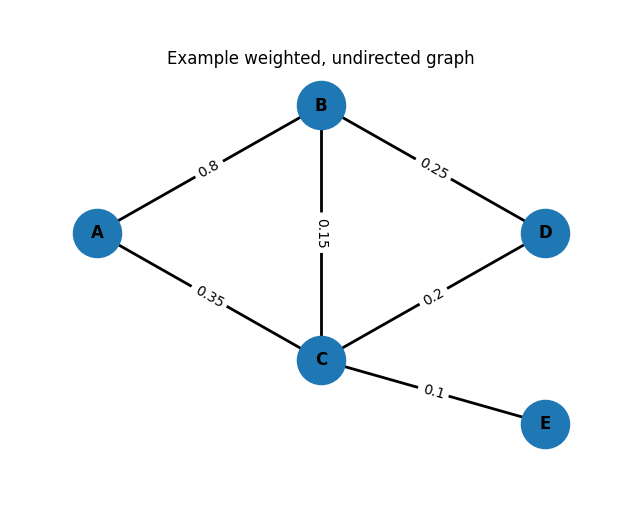

In [14]:
# Create a small weighted graph
G_example = nx.Graph()

edges = [
    ("A", "B", 0.80),
    ("A", "C", 0.35),
    ("B", "D", 0.25),
    ("C", "D", 0.20),
    ("B", "C", 0.15),
    ("C", "E", 0.10),
]

G_example.add_weighted_edges_from(edges)

# Fixed positions for a clean layout
pos = {
    "A": (0, 1),
    "B": (1, 2),
    "C": (1, 0),
    "D": (2, 1),
    "E": (2, -0.5),
}

plt.figure(figsize=(7,5))

# Draw nodes
nx.draw_networkx_nodes(
    G_example,
    pos,
    node_size=1200,
)

# Draw edges
nx.draw_networkx_edges(
    G_example,
    pos,
    width=2,
)

# Draw node labels
nx.draw_networkx_labels(
    G_example,
    pos,
    font_size=12,
    font_weight="bold",
)

# Draw edge-weight labels
edge_labels = nx.get_edge_attributes(G_example, "weight")
nx.draw_networkx_edge_labels(
    G_example,
    pos,
    edge_labels=edge_labels,
    font_size=10,
)

plt.title("Example weighted, undirected graph")
plt.axis("off")
plt.show()

### Nodal degree

Suppose Region A is connected to Regions **B** and **C**, but not to Region **D**.

Because Region A has **two connections**, its **degree** is

$$
\mathrm{Degree}(A)=2.
$$

Degree simply counts **how many edges are connected to a node**. It does **not** consider how strong those connections are.

### Nodal strength

Now suppose those two connections have different strengths:

- Region A ↔ Region B = **0.80**
- Region A ↔ Region C = **0.35**

The **strength** of Region A is simply the sum of the weights of all of its connections:

$$
\mathrm{Strength}(A)=0.80+0.35=1.15.
$$

Unlike degree, **strength takes the edge weights into account**. A node with many weak connections and a node with a few strong connections may have very different strengths even if their degrees are similar.

### Normalized nodal strength

The raw strength of a node depends on how many other nodes exist in the network. For example, a brain network with **100 regions** has many more possible connections than one with **50 regions**, so the raw strength values are naturally larger.

To make strength values easier to compare, we often compute the **normalized strength** by dividing the raw strength by the maximum possible number of neighbours:

$$
\mathrm{Normalized\ strength}
=
\frac{\mathrm{Strength}}{N-1},
$$

where \(N\) is the total number of nodes in the network.

For our previous example, suppose the network contains **5 nodes** (A–E). Region A has a strength of

$$
1.15.
$$

Since Region A could connect to at most **4** other nodes, its normalized strength is

$$
\frac{1.15}{5-1}
=
\frac{1.15}{4}
=
0.2875.
$$

You can think of the normalized strength as the **average connection strength per possible neighbour**. This makes the values easier to interpret and compare across networks with different numbers of nodes.

### Degree versus strength

The difference can be illustrated with a simple example.

| Node | Connections | Degree | Strength |
|------|-------------|:------:|:--------:|
| A | 0.80, 0.35 | 2 | 1.15 |
| B | 0.25, 0.20, 0.15, 0.10 | 4 | 0.70 |

Although **Node B** has the **higher degree** (four connections versus two), **Node A** has the **higher strength** because its connections are much stronger.

### Code

Now, let's compute nodal degree and strength for our LEMON dataset! Recall that our FC has 100 nodes. Below, the code will

The code below will:

- compute the **degree** of every node (the number of connections each brain region has),
- compute the **strength** of every node (the sum of the weights of all connections to that brain region),
- store these values as **node attributes** within the NetworkX graph so they can be used in later analyses,
- compute the **normalized strength** by dividing each node's strength by the maximum possible number of neighbours (\(N-1\)),
- summarize the degree and strength values in a table for every brain region,
- calculate the **mean degree** and **mean normalized strength** across the network, and
- display the **10 brain regions with the highest nodal strength**.



In [15]:
# Try using different thresholded graphs
G = G_50

# Compute nodal degree and nodal strength
degree = dict(G.degree())                       # number of neighbors for each node
strength = dict(G.degree(weight="weight"))      # weighted degree / strength

# Store them as node attributes
nx.set_node_attributes(G, degree, "degree")
nx.set_node_attributes(G, strength, "strength")

# Normalize strength by the number of possible neighbors (N - 1)
n_nodes = G.number_of_nodes()
norm_strength = {node: val / (n_nodes - 1) for node, val in strength.items()}
nx.set_node_attributes(G, norm_strength, "strength_norm")

# A simple summary table
node_metrics = pd.DataFrame(
    {
        "degree": pd.Series(degree),
        "strength": pd.Series(strength),
        "strength_norm": pd.Series(norm_strength),
    }
).fillna(0)

mean_degree = node_metrics["degree"].mean()
mean_strength_norm = node_metrics["strength_norm"].mean()

print("Mean degree:", round(mean_degree, 4))
print("Mean normalized strength:", round(mean_strength_norm, 4))

# Show the nodes with the strongest connections
node_metrics.sort_values("strength", ascending=False).head(10)


Mean degree: 17.16
Mean normalized strength: 0.1063


,degree,strength,strength_norm
7Networks_LH_SomMot_3,31,19.945241,0.201467
7Networks_RH_SalVentAttn_Med_2,31,19.088667,0.192815
7Networks_LH_DorsAttn_FEF_1,32,18.922569,0.191137
7Networks_RH_SomMot_1,30,18.410590,0.185966
7Networks_LH_SomMot_1,30,18.332978,0.185182
7Networks_RH_SalVentAttn_Med_1,31,18.111438,0.182944
7Networks_RH_DorsAttn_FEF_1,30,18.109648,0.182926
7Networks_RH_DorsAttn_Post_5,30,18.048017,0.182303
7Networks_LH_SalVentAttn_Med_2,31,18.030235,0.182124
7Networks_LH_DorsAttn_Post_6,29,17.466410,0.176428


## Centrality: which nodes sit in important positions?

Centrality measures try to answer a simple question:

> Which nodes are especially important in the network?

Different centrality measures define “important” in different ways.

- **Degree centrality** (same as nodal degree): nodes that are connected to many other nodes.
- **Closeness centrality**: nodes that can reach many other nodes through relatively short paths.
- **Betweenness centrality**: nodes that lie on many shortest paths and therefore act as bridges between different parts of the network.
- **Eigenvector centrality**: nodes that are connected to other highly connected or influential nodes.

Because our edge weights are similarities (larger values = stronger relationships), we convert them into distances by taking the inverse weight before computing path-based measures. In that distance view, stronger correlations become shorter distances.

In [16]:
# ------------------------------------------------------------------
# Step 1: Select the graph we want to analyze (e.g., G_full, G_50, G_75)
# ------------------------------------------------------------------

G = G_full

# ------------------------------------------------------------------
# Step 2: Create a distance graph
# ------------------------------------------------------------------

# Many graph measures (e.g., shortest paths and closeness centrality)
# work with distances rather than connection strengths.
#
# In our FC network, larger weights mean two regions are MORE strongly
# connected. However, shortest-path algorithms assume that
# smaller values represent SHORTER distances.
#
# Therefore, we convert each edge weight into a distance using:
#
# distance = 1 / weight
#
# Strong connections therefore become short distances,
# while weak connections become long distances.

# Loop over every edge in the graph.
#
# For each edge:
#   u = the first node
#   v = the second node
#   d = a dictionary containing information about that edge
#       (such as its weight)
#
# For example, one edge might look like:
#
#   u = "Region_A"
#   v = "Region_B"
#   d = {"weight": 0.82}
#
# Because d is a dictionary, we can access the edge weight
# using d["weight"].

G_dist = nx.Graph()
G_dist.add_nodes_from(G.nodes())

for u, v, d in G.edges(data=True):

    w = d["weight"]

    if w > 0:
        G_dist.add_edge(
            u,
            v,
            weight=1.0 / w,
        )


# ------------------------------------------------------------------
# Step 3: Ensure the graph is connected
# ------------------------------------------------------------------
# Path-based centrality measures assume that every node
# can be reached from every other node.
#
# Check that the graph is connected before proceeding.

if not nx.is_connected(G_dist):
    raise ValueError(
        "The graph is disconnected. "
        "Path-based centrality measures (e.g., closeness and betweenness) "
        "require a connected graph. "
        "Try using a lower threshold or analyse each connected component separately."
    )

centrality_graph = G_dist


# ------------------------------------------------------------------
# Step 4: Compute the centrality measures
# ------------------------------------------------------------------

# Closeness centrality:
# Nodes that can reach other nodes through relatively short paths.
closeness = nx.closeness_centrality(
    centrality_graph,
    distance="weight",
)

# Betweenness centrality:
# Nodes that lie on many shortest paths.
betweenness = nx.betweenness_centrality(
    centrality_graph,
    weight="weight",
    normalized=True,
)

# Eigenvector centrality:
# Nodes connected to other influential nodes.
eigenvector = nx.eigenvector_centrality(
    G,
    weight="weight",
    max_iter=1000,
)

# PageRank (another type of centrality measure)
pagerank = nx.pagerank(
    G,
    weight="weight",
)

# ------------------------------------------------------------------
# Step 5: Combine the results into one table
# ------------------------------------------------------------------

centrality_df = pd.DataFrame(
    {
        "closeness":
            pd.Series(closeness)
            .reindex(G.nodes(), fill_value=0),

        "betweenness":
            pd.Series(betweenness)
            .reindex(G.nodes(), fill_value=0),

        "eigenvector":
            pd.Series(eigenvector)
            .reindex(G.nodes(), fill_value=0),

        "pagerank":
            pd.Series(pagerank)
            .reindex(G.nodes(), fill_value=0),
    }
)

centrality_df.head()

,closeness,betweenness,eigenvector,pagerank
7Networks_LH_Vis_1,0.326769,0.004947,0.097145,0.010017
7Networks_LH_Vis_2,0.338885,0.001237,0.113180,0.011040
7Networks_LH_Vis_3,0.335871,0.000206,0.111934,0.010830
7Networks_LH_Vis_4,0.262862,0.000000,0.081664,0.008449
7Networks_LH_Vis_5,0.295010,0.000206,0.095680,0.009673


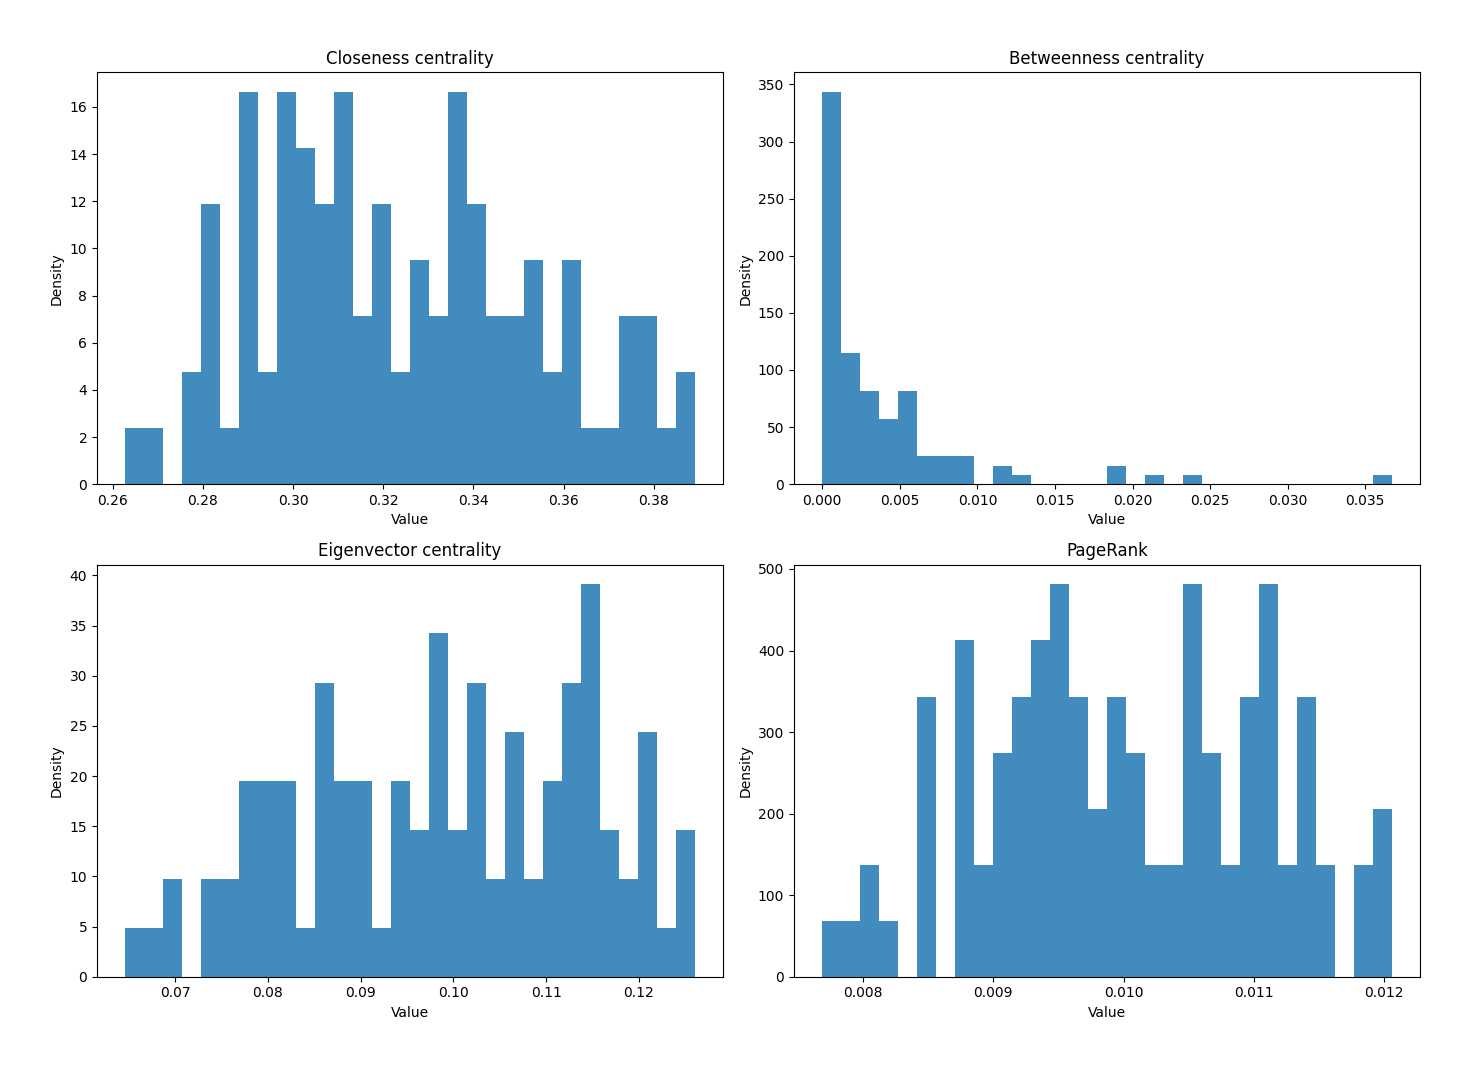

In [17]:
# Visualize the distribution of centrality values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

centrality_specs = [
    ("closeness", "Closeness centrality"),
    ("betweenness", "Betweenness centrality"),
    ("eigenvector", "Eigenvector centrality"),
    ("pagerank", "PageRank"),
]

for ax, (col, title) in zip(axes.flat, centrality_specs):
    ax.hist(centrality_df[col], bins=30, density=True, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


## Shortest path length and average path length

A **shortest path** is the shortest route between two nodes.

Remember, because our FC weights measure similarity, we first convert them into distances using the inverse relationship:

- strong connection → short distance
- weak connection → long distance

The **average path length** is the average shortest distance between all pairs of nodes. It is often used as a simple summary of how efficiently information can move through the network.

In [18]:
# Pick two random brain regions to illustrate a shortest path
path_nodes = list(centrality_graph.nodes())

if len(path_nodes) < 2:
    raise ValueError("Need at least two nodes to compute a shortest path.")

# Randomly select two different brain regions
source, target = np.random.choice(path_nodes, size=2, replace=False)

# Compute the shortest path and its total weighted length
shortest_path = nx.shortest_path(
    centrality_graph,
    source=source,
    target=target,
    weight="weight",
)
shortest_path_length = nx.shortest_path_length(
    centrality_graph,
    source=source,
    target=target,
    weight="weight",
)

print("Source node:", source)
print("Target node:", target)
print("Shortest path:", shortest_path)
print("Shortest path length:", round(shortest_path_length, 4))

# Compute the average shortest path length across the whole graph
average_path_length = nx.average_shortest_path_length(
    centrality_graph,
    weight="weight",
)
print("Average shortest path length:", round(average_path_length, 4))

Source node: 7Networks_LH_SalVentAttn_Med_1
Target node: 7Networks_LH_SalVentAttn_FrOperIns_1
Shortest path: [np.str_('7Networks_LH_SalVentAttn_Med_1'), '7Networks_LH_SalVentAttn_FrOperIns_1']
Shortest path length: 1.7498
Average shortest path length: 3.1139


## Modularity, assortativity, clustering, and the minimum spanning tree

These metrics describe the **global** organization of the network.



### Modularity

Imagine looking at a map of friendships in a school.

Do students naturally separate into groups where **friends are more connected to each other than to everyone else**?

Graph theory asks the same question for the brain:

> **Are there groups of brain regions that interact more strongly with one another than with the rest of the brain?**

These groups are called **modules** or **communities**.

For example, regions involved in visual processing may communicate more strongly with one another than with regions involved in language or memory.

In other words, **modularity** measures **how well a network can be divided into communities**.

A network has **high modularity** when:

* there are **many connections within each community**, and
* relatively **few connections between communities**.

Conversely, if connections are distributed almost randomly throughout the network, modularity is low because there are no clearly defined communities.

Rather than manually assigning communities, we will use a community-detection algorithms in network neuroscience. It automatically searches for a partition of the network that maximizes modularity.

---

### Assortativity

Suppose we look only at the **highly connected regions** of the brain.

Do they tend to connect to **other highly connected regions**?

Or do they mostly connect to regions that have very few connections?

Assortativity measures this tendency.

In other words, assortativity describes **whether similar nodes tend to connect to one another**.

In network neuroscience, similarity is often measured using **node degree**.

* **Positive assortativity:** highly connected nodes preferentially connect to other highly connected nodes.
* **Negative assortativity:** highly connected nodes tend to connect to weakly connected nodes.

Assortativity therefore tells us something about the overall organization and resilience of the network.

---

### Clustering coefficient

Let's say you have two close friends.

How likely is it that **those two friends also know each other?**

If they do, they form a small triangle.

Graph theory asks exactly the same question.

Suppose brain region **A** connects to regions **B** and **C**.

> **Are B and C also connected to each other?**

If they are, the three regions have high clustering coefficient. 

Thus, the **clustering coefficient** measures **the tendency for any two neighbours of a node to be directly connected**. 

A high clustering coefficient means that neighbouring brain regions are also strongly interconnected, forming tightly connected local neighbourhoods.

In weighted networks such as ours, the clustering coefficient also incorporates the **strength of the connections**, not just whether they exist.

It therefore reflects both the **number** and the **strength** of local triangular connections.

---

### Minimum Spanning Tree (MST)

Imagine you are designing a railway network connecting several cities.

You want to:

* connect **every city**,
* use the **fewest possible tracks**, and
* avoid building unnecessary loops that increase cost.

The idea behind the **minimum spanning tree** is similar to this.

The minimum spanning tree (MST) is the **smallest set of edges that still connects every node in the network**.

For a network containing (N) nodes, the MST always contains exactly `N-1` edges.

Because it contains no cycles, there is **exactly one unique path** between any pair of nodes.

When constructing the MST from a functional connectivity network, the algorithm preferentially keeps the **strongest functional connections** (equivalently, the shortest distances after our weight-to-distance transformation), while discarding redundant edges.

In this tutorial, we will use **Kruskal's algorithm**, which builds the tree one edge at a time. Starting with the strongest available connections, it adds an edge only if doing so **does not create a loop**. The process continues until every brain region is connected.

---

### Summary:
- Modularity: Modularity helps identify groups of brain regions that tend to work together as functional systems or networks.
- Assortativity: Assortativity helps us understand whether highly connected brain regions preferentially connect to other highly connected regions.
- Clustering coefficient: The clustering coefficient helps quantify how tightly interconnected the neighbouring brain regions around a particular region are.
- Minimum spanning tree (MST): The minimum spanning tree helps reveal the backbone of the brain network by preserving only the strongest connections needed to keep all brain regions connected.

In [19]:
# Modularity
communities = nx.community.louvain_communities(G, weight="weight", seed=42)
# communities = list(nx.algorithms.community.greedy_modularity_communities(G, weight="weight"))
modularity_score = nx.algorithms.community.modularity(G, communities, weight="weight")

# Assortativity: similarity of node degree across edges
assortativity_score = nx.degree_pearson_correlation_coefficient(G, weight="weight")

# Clustering coefficient: how interconnected a node's neighbors are
clustering = nx.clustering(G, weight="weight")
average_clustering = nx.average_clustering(G, weight="weight")

# Build a distance graph for the minimum spanning tree
G_mst_dist = nx.Graph()
G_mst_dist.add_nodes_from(G.nodes())

for u, v, d in G.edges(data=True):
    w = d["weight"]
    if w > 0:
        G_mst_dist.add_edge(u, v, weight=1.0 / w)

MST = nx.minimum_spanning_tree(G_mst_dist, weight="weight")

print("Number of communities:", len(communities))
print("Modularity:", round(modularity_score, 4))
print("Assortativity:", round(assortativity_score, 4))
print("Average clustering coefficient:", round(average_clustering, 4))
print("MST edges:", MST.number_of_edges())


Number of communities: 3
Modularity: 0.1298
Assortativity: -0.0101
Average clustering coefficient: 0.3292
MST edges: 99


### Visualizing communities

In the figure below,

- each circle represents one brain region,
- the **colour** indicates the community (module) assigned by the Louvain algorithm,
- the **size** of each node is proportional to its normalized nodal strength, and
- the numbers (**1–100**) correspond to the Schaefer-100 brain regions.

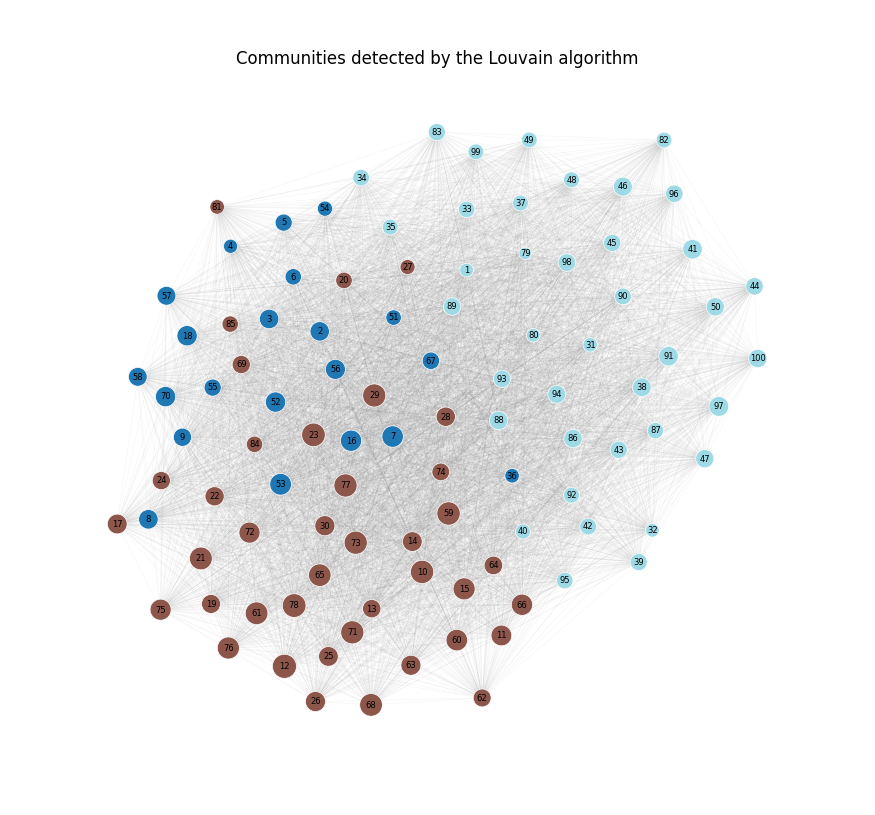

In [20]:
# ----------------------------------------------------------
# Visualize communities detected by the Louvain algorithm
# ----------------------------------------------------------

# Create simple numeric labels (1–100)
node_list = list(G.nodes())
node_labels = {node: str(i + 1) for i, node in enumerate(node_list)}

# Map each node to its community
community_lookup = {}
for community_index, community in enumerate(communities):
    for node in community:
        community_lookup[node] = community_index

community_colors = [community_lookup[node] for node in node_list]

# Scale node sizes according to normalized strength
node_sizes = np.array([norm_strength[node] for node in node_list])
node_sizes = 80 + 220 * (
    (node_sizes - node_sizes.min())
    / (node_sizes.max() - node_sizes.min() + 1e-12)
)

# Compute node positions
pos = nx.spring_layout(
    G,
    seed=42,
    weight="weight",
    k=0.35,
)

plt.figure(figsize=(10, 9))

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.08,
    width=0.4,
    edge_color="gray",
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=community_colors,
    cmap="tab20",
    edgecolors="white",
    linewidths=0.5,
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=node_labels,
    font_size=6,
)

plt.title("Communities detected by the Louvain algorithm")
plt.axis("off")
plt.show()

### Visualizing the minimum spanning tree

Unlike the original functional brain network, the minimum spanning tree contains only the **minimum number of edges required to connect every brain region**.

Notice that the network is much sparser than the original graph. Every brain region remains connected, but redundant connections have been removed, revealing the network's connectivity backbone.

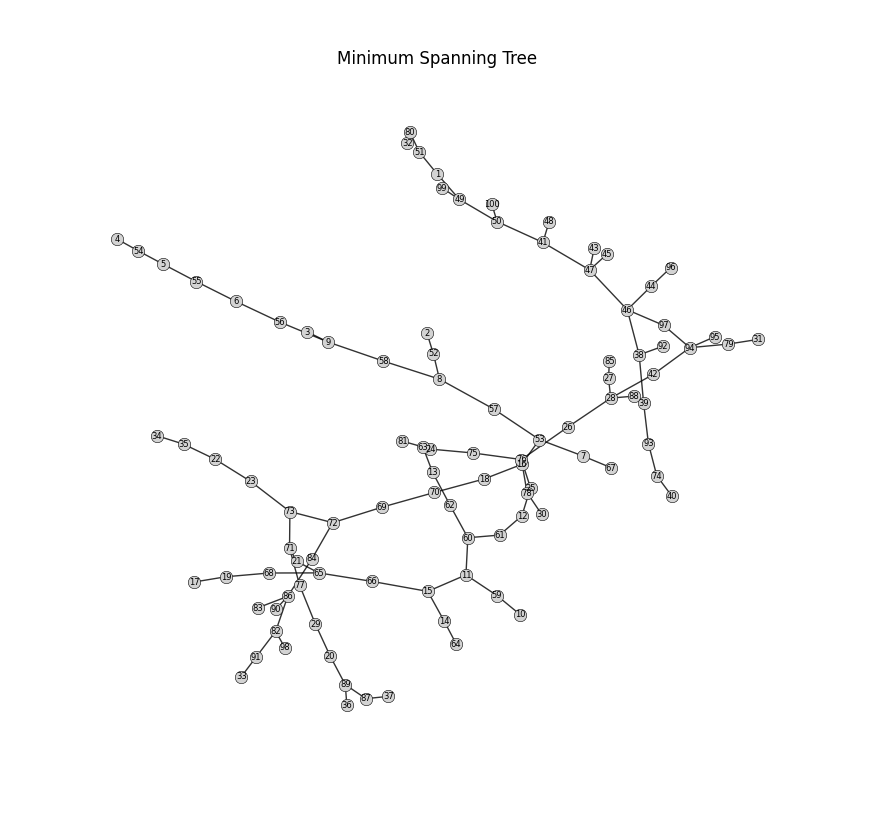

In [21]:
# ----------------------------------------------------------
# Visualize the Minimum Spanning Tree (MST)
# ----------------------------------------------------------

mst_pos = nx.spring_layout(
    MST,
    seed=42,
    weight="weight",
)

plt.figure(figsize=(10, 9))

nx.draw_networkx_edges(
    MST,
    mst_pos,
    width=1.0,
    alpha=0.8,
)

nx.draw_networkx_nodes(
    MST,
    mst_pos,
    node_size=80,
    node_color="lightgray",
    edgecolors="black",
    linewidths=0.4,
)

nx.draw_networkx_labels(
    MST,
    mst_pos,
    labels=node_labels,
    font_size=6,
)

plt.title("Minimum Spanning Tree")
plt.axis("off")
plt.show()

## Visualizing the network with a circos plot

As the number of brain regions increases, visualizing a functional brain network using a traditional node-link diagram becomes increasingly difficult because many edges overlap and clutter the figure.

A **circos plot** provides an alternative visualization by arranging all brain regions around the circumference of a circle and drawing the functional connections between them as curved links.

Circos plots are particularly useful for:

- visualizing the **overall organization** of a brain network,
- observing how strongly different functional networks interact with one another, and
- comparing connectivity patterns across individuals, experimental conditions, or clinical populations.

In the plot below:

- each number (**1–100**) represents one brain region,
- the colour of each node indicates its large-scale functional network,
- and each curved line represents a functional connection between two brain regions.

Because displaying every connection would produce a highly cluttered figure, circos plots are typically generated using a **thresholded network**, allowing the strongest functional connections to be visualized more clearly.

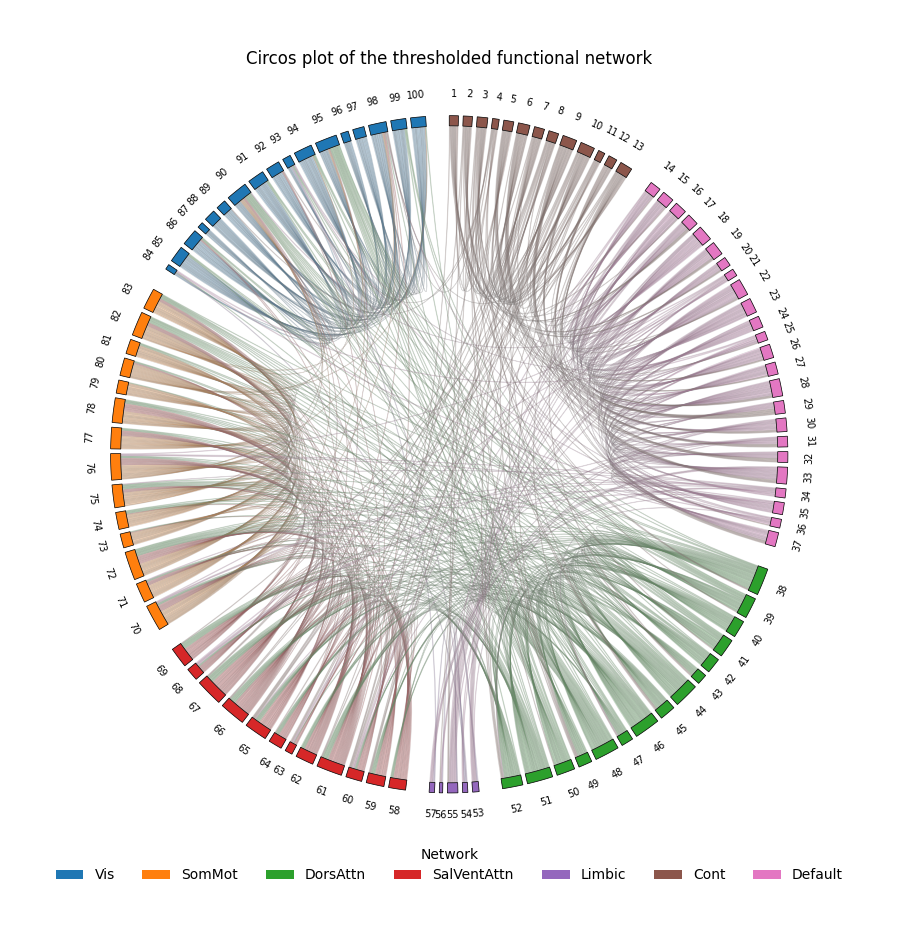

In [22]:
# ----------------------------------------------------------
# 1) Build metadata from atlas labels
# ----------------------------------------------------------
node_meta = pd.DataFrame({"region_name": region_names})

parts = node_meta["region_name"].str.split("_")
node_meta["atlas"] = parts.str[0]
node_meta["hemisphere"] = parts.str[1]
node_meta["network"] = parts.str[2]
node_meta["region_id"] = parts.str[3]

# Order by network, then hemisphere, then region name
node_meta = node_meta.sort_values(
    ["network", "hemisphere", "region_name"]
).reset_index(drop=True)

# Keep circos labels as 1..100
node_meta["node_label"] = np.arange(1, len(node_meta) + 1).astype(str)

# Lookup tables
region_to_label = dict(zip(node_meta["region_name"], node_meta["node_label"]))
label_to_network = dict(zip(node_meta["node_label"], node_meta["network"]))

# ----------------------------------------------------------
# 2) Relabel the graph to 1..100
# ----------------------------------------------------------

G_circos = G_50.copy() # Use a thresholded graph so the circos plot stays readable.
G_circos = nx.relabel_nodes(G_50.copy(), region_to_label)

# ----------------------------------------------------------
# 3) Build the adjacency matrix in the desired order
# ----------------------------------------------------------
ordered_labels = node_meta["node_label"].tolist()
adj = nx.to_pandas_adjacency(G_circos, nodelist=ordered_labels, weight="weight")

# For an undirected graph, keep only one copy of each edge
adj_upper = adj.where(np.triu(np.ones(adj.shape), k=1).astype(bool), 0)

# ----------------------------------------------------------
# 4) Define fixed colors for the 7 networks
# ----------------------------------------------------------
network_palette = {
    "Vis": "#1f77b4",
    "SomMot": "#ff7f0e",
    "DorsAttn": "#2ca02c",
    "SalVentAttn": "#d62728",
    "Limbic": "#9467bd",
    "Cont": "#8c564b",
    "Default": "#e377c2",
}

# Map each node label to its network color
node_color_map = {
    row.node_label: network_palette.get(row.network, "#bbbbbb")
    for row in node_meta.itertuples(index=False)
}

# ----------------------------------------------------------
# 5) Add larger gaps between networks
# ----------------------------------------------------------
spaces = [0.8] * len(ordered_labels)
for i in range(len(ordered_labels) - 1):
    if node_meta.loc[i, "network"] != node_meta.loc[i + 1, "network"]:
        spaces[i] = 4.0
spaces[-1] = 4.0

# ----------------------------------------------------------
# 6) Draw the chord diagram
# ----------------------------------------------------------
circos = Circos.chord_diagram(
    adj_upper,
    space=spaces,
    cmap=node_color_map,
    label_kws=dict(size=7),
    link_kws=dict(alpha=0.25, lw=0.5),
)

fig = circos.plotfig()

# ----------------------------------------------------------
# 7) Add a small legend underneath
# ----------------------------------------------------------
legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=network)
    for network, color in network_palette.items()
]

fig.legend(
    handles=legend_handles,
    title="Network",
    loc="lower center",
    ncol=7,
    frameon=False,
    bbox_to_anchor=(0.5, -0.075),
)

plt.title("Circos plot of the thresholded functional network")
plt.show()

# Exercise: Compute Graph Theoretical Measures for the Entire Dataset

Throughout this tutorial, we have computed graph-theoretical measures for the **group-average functional connectivity matrix**. This allowed us to understand what each graph measure represents and how it is computed.

In practice, however, neuroimaging studies rarely analyse only a single graph. Instead, we typically compute graph-theoretical measures for **every participant** and then compare these measures across participants, experimental groups, or behavioural variables.

Your task is to extend what you have learned in this tutorial to the **entire LEMON dataset**.

## Objective

Write a Python script that computes graph-theoretical measures for **every participant** in the dataset.

As in this tutorial, calculate these measures for three different graph constructions:

- **G_full**: the full weighted graph (no threshold),
- **G_50**: thresholded at a weight of 0.50,
- **G_25**: thresholded at a weight of 0.25.

Store your results in two separate dataframes:

1. **Node-level metrics** (one row per subject × graph × brain region)
2. **Graph-level metrics** (one row per subject × graph)

---

## Suggested approach

In programming, it's helpful to break the problem into smaller pieces.

For example:

1. **Load** the saved FC matrices from Tutorial 2 (`subject_fc_stack.npy`). (already done in this tutorial)
2. Write a helper function that converts a subject's FC matrix into a graph.
3. Write another helper function that computes the graph-theoretical measures for a single graph and outputs arrays/dataframe(s)
4. Create a loop over every participant and types of graph.
5. For each participant, construct the three graphs (**G_full**, **G_50**, and **G_25**).
6. Compute the graph measures for each graph.
7. Append the results to two lists of dataframes (e.g., one node-level dataframe and one subject-level for global measures)
8. Concatenate everything into one node-level dataframe and one graph-level dataframe.
9. Save both dataframes into your `results/` directory.

---

## Things to think about

Before writing your code, consider the following questions.

- Which graph measures produce **one value per brain region**, and which produce **one value per graph**?
- How will you keep track of which participant each result belongs to?
- How will you distinguish between results from **G_full**, **G_50**, and **G_25**?
- Some graph measures require a **connected graph**. What should your code do if a thresholded graph becomes disconnected?

---

## Expected outputs

By the end of the exercise, you should have two dataframes:

- **Node-level graph metrics**, containing one row for every brain region in every participant and graph.
- **Graph-level graph metrics**, containing one row for every participant and graph.

These dataframes will form the basis for the statistical analyses in the next tutorial.

In [ ]:
# Sample Code

# -------------------------------------------------------------------
# Create helper functions
# -------------------------------------------------------------------

# Create a function (input: FC, threshold level) that returns a (thresholded) graph
def make_graph(mat, threshold=None):
    matrix = np.array(mat, dtype=float, copy=True)

    # Absolutize FC matrix (use np.abs)
    # --- fill in code here --- #

    # Threshold the matrix
    if threshold is not None: # if threshold value is provided (i.e., not None)
        # ... fill in code here to threshold the matrix ...
        matrix = '' # change this line

    # Write code below to create graph G and remove self edges
    # --- fill in code here --- #

    # Function returns a graph G
    return G

# Create a function that computes metrics from graph G and output the dataframe
def compute_metrics(G):
    # If graph not connected, return nothing
    if not nx.is_connected(G):
        return None, None

    # Write code below to calculate distance 
    G_dist = nx.Graph()
    # --- fill in code here --- #

    # Write code below to calculate metrics (e.g,. degree, strength, centrality measures, modularity, etc.)
    node_order = list(G.nodes()) 
    degree = pd.Series(dict(G.degree())).reindex(node_order) # Use pd.Series to rearrange the values so they follow exactly the order stored in node_order
    # --- continue here --- #


    # Edit (and uncomment) the code below to create dataframe (e.g., )
    '''    
    node_df = pd.DataFrame(
        {
            "region": node_order,
            "degree": ...,
            ...
        }
    )'''

    '''
    global_df = pd.DataFrame(
        [{
            "n_nodes": G.number_of_nodes(),
            ....
        }]
    )
    '''

    # Use return to output node_df and global_df



In [ ]:
# -------------------------------------------------------------------
# Code utilizing the above functions
# -------------------------------------------------------------------

# -------------------------------------------------------------------
# Specify the graph types that will be analysed.
# The key is the graph name, and the value is the threshold used
# when constructing the graph.
# -------------------------------------------------------------------
graph_specs = {
    "G_full": None,
    "G_50": 0.50,
}

# -------------------------------------------------------------------
# Create two empty lists that will store the results.
#
# node_frames:
#     One dataframe per subject × graph containing node-level metrics.
#
# graph_frames:
#     One dataframe per subject × graph containing graph-level metrics.
# -------------------------------------------------------------------
node_frames = []
graph_frames = []


# -------------------------------------------------------------------
# Loop through every participant in the dataset.
#
# For each participant, build each graph (G_full, G_50, ...)
# and compute the graph-theoretical measures.
# -------------------------------------------------------------------
for sid, subj_mat in zip(subject_ids, fc_stack):

    for graph_name, thr in graph_specs.items():

        # Construct the requested graph from this participant's
        # functional connectivity matrix.
        G = make_graph(subj_mat, threshold=thr)

        # Some graph measures require a connected graph.
        # Skip this graph if it is disconnected.
        if not nx.is_connected(G):
            print(f"Skipping {sid} | {graph_name}: disconnected")
            continue

        # Compute both node-level and graph-level metrics.
        node_df, global_df = compute_metrics(G)

        # Record which participant and graph each row belongs to.
        node_df.insert(0, "graph", graph_name)
        node_df.insert(0, "subject_id", sid)

        global_df.insert(0, "graph", graph_name)
        global_df.insert(0, "subject_id", sid)

        # Save this participant's results.
        node_frames.append(node_df)
        graph_frames.append(global_df)


# -------------------------------------------------------------------
# Combine the individual dataframes into one large dataframe.
#
# The resulting tables contain graph metrics for every participant.
# -------------------------------------------------------------------
node_metrics_df = pd.concat(node_frames, ignore_index=True)
graph_metrics_df = pd.concat(graph_frames, ignore_index=True)

# Write code below to export them into .csv files
# --- fill in code here --- #
